# Causal Time Series Selection for high dimensional MTS


## Setup

To be safe, start this notebook in a clean virtual environment.

For those who use VSCode, you can use Select Kernel then Select another Kernel then create a new python environment.

For those who use a local Jupyter install, you may want to follow: https://ipython.readthedocs.io/en/latest/install/kernel_install.html

For those who use google colab, you may want to use the following code, setting plateform to "colab".

In [ ]:
plateform = None
# On colab
if plateform == "colab":
  !pip3 install virtualenv
  !virtualenv --system-site-packages .env
  !source /content/.env/bin/activate

Make sure that the virtual environment is activated in your notebook.

Install the ChronoEpilogi package in your environment. Restart the kernel if necessary.

In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


In [ ]:
!pip3 install git+https://github.com/ev07/minimal_chronoepilogi.git

  Cloning https://github.com/ev07/minimal_chronoepilogi.git to /tmp/pip-req-build-l_7c3l_t
  Running command git clone --filter=blob:none --quiet https://github.com/ev07/minimal_chronoepilogi.git /tmp/pip-req-build-l_7c3l_t
  Resolved https://github.com/ev07/minimal_chronoepilogi.git to commit d74405b7db5acde17870d71fe767665e609a956a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 22.3 MB/s eta 0:00:00
  Created wheel for chronoepilogi: filename=chronoepilogi-0.0.1-py3-none-any.whl size=39996 sha256=0dbeb059820471c62c6cd2bdd0a8ca9d8c36c01d3aa42ca63c70386d11703173
  Stored in directory: /tmp/pip-ephem-wheel-c

In [ ]:
import chronoepilogi

In [ ]:
# Other libraries required in the Lab that you may need to install
!pip3 install skforecast
!pip3 install networkx
!pip3 install lightgbm
import networkx as nx
import skforecast.direct._forecaster_direct_multivariate
from lightgbm import LGBMRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.7/415.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

import tigramite.data_processing
import tigramite.pcmci
import tigramite.independence_tests.parcorr
import time

import matplotlib.pyplot as plt
import statsmodels
import scipy

## Part 1 - Time Series Selection under Faithfulness

We will begin experimenting on a Structural Causal Model that we will define ourselves, with **synthetic data**. This will allow us to generate controlled data, apply the algorithm and verify against a ground truth that the Markov Boundaries are correct.

We will define a Structural Causal Model as follows.
 - We will generate iid standard gaussian noise $(U^i_t)^{1\leq i \leq D}_{1\leq t \leq T}$
 - We will define for each TS a set of parents $Parents(X^i_t)$, that will be identical (invariant) along time.
 - We will define for each TS a functional dependency $f_{i,t}$ of the noise and parents. They will be identical (invariant) along time, and the overall process will as a result be stationary.

Finally, we will generate a very large sample size to be sure that we have accurate tests. In the code, T is set to 20000 for that purpose.

In [154]:
D = 5  # covariates
T = 20000   # sample size
L = 1  # only 1 lags (markovian process) to begin
p = 1  # 1 parent only other than the autoregressive component

### Q1 - Create a function to generate a noise numpy matrix of size D x T, iid standard gaussian. The function prototype should include a numpy generator object `https://numpy.org/devdocs/reference/random/generator.html`, which will be used to obtain the noise.

In [155]:
def generate_noise(D, T, rng_object):
  return rng_object.standard_normal((D,T))

  # TODO

In [156]:
# TEST
noise_matrix = generate_noise(D,T,np.random.default_rng(0))
noise_matrix.shape

(5, 20000)

### Q2 - Create function that generates the parents as a numpy matrix of shape (D,D,L).

The matrix will encode the parents: $mat[cause][effect][k]$ should be 1 if $X^{cause}_{t-L+k}\in Parents(X^{effect}_t)$, 0 otherwise.

We will model both autoregressive component and covariate interaction:
 - Set an autoregressive component so that $mat[effect][effect][L-1]=1$.
 - Your function will draw randomly $p$ other distinct parents for each effect (distinct from the effect), and the temporality $k$ of the link will be chosen uniformly randomly with $0\leq k <L$. Note that the number of other parents `p` was defined before as 1.



The function will take as argument D and L, the number of parents per cause $p$, and a numpy random generator object which will be used to select the parents.

In [157]:
def generate_parents(D, L, p, rng_object):
  parent_matrix = np.zeros((D, D, L))
  for i in range(D):
    parent_matrix[i, i, L-1] = 1
  for child_idx in range(D):
    potential_parents_indices = [i for i in range(D) if i != child_idx]
    selected_parents = rng_object.choice(potential_parents_indices, size=p, replace=False)
    for parent_idx in selected_parents: # autoregressive component
        lag_k = rng_object.integers(0, L)
        parent_matrix[parent_idx, child_idx, lag_k] = 1

  return parent_matrix

In [158]:
parent_matrix = generate_parents(D,L,p,np.random.default_rng(0))
parent_matrix.shape

(5, 5, 1)

Once, this is done, run the following to get positive coefficients of a stationary linear functional model.

The transition function to generate $X^i_t$ from $X^{1:D}_{t-L:t-1}$ is $f(X^{1:D}_{t-L:t-1},U^i_t) = noisemat[i,t] + np.sum(coefficientmat[:,i,:]*X^{1:D}_{t-L:t-1})$


In [159]:
def generate_coefficients(parent_matrix, rng_object):
  coefficient_matrix = rng_object.uniform(0.5, 1, parent_matrix.shape)
  coefficient_matrix = coefficient_matrix * parent_matrix
  coefficient_matrix = 0.9*coefficient_matrix / np.sum(coefficient_matrix, axis=(0,2))[np.newaxis,:,np.newaxis]  # enforces stationarity.
  return coefficient_matrix


In [160]:
coefficient_matrix = generate_coefficients(parent_matrix, np.random.default_rng(0))
coefficient_matrix.shape

(5, 5, 1)

Run the following to obtain a realization of the MTS.

In [161]:
def varsim(coefficient_matrix,noise_matrix):
  D,T = noise_matrix.shape
  _,_,L = coefficient_matrix.shape
  observation_matrix = np.zeros((D,T))
  observation_matrix[:,:L] = noise_matrix[:,:L]
  for t in range(L,T):
    total_effect = np.einsum('pck,pk->c', coefficient_matrix, observation_matrix[:, t-L:t])
    observation_matrix[:,t] = noise_matrix[:,t] + total_effect
  return observation_matrix

In [162]:
observation_matrix = varsim(coefficient_matrix,noise_matrix)
# result of the sum of the 2 effects (will be our data)
observation_matrix.shape
print(observation_matrix)

[[ 0.12573022 -0.20556764  0.82150069 ... -3.83522132 -2.44931677
  -2.11334755]
 [ 0.32359472  0.89244049  0.40873426 ... -1.36470976 -1.14989426
  -2.19482135]
 [ 0.17576265 -0.64035754 -0.62391976 ...  0.48779165  0.01949038
  -2.19341907]
 [-0.76329054 -0.20730431 -0.12339322 ... -0.50120897 -0.98226035
  -2.23794751]
 [-0.41171045  0.8487197   0.72025664 ... -2.12177411 -2.63469312
  -2.13831541]]


## Q3 - Visualize the Causal Graph of the generated SCM.

NetworkX is a python library allowing simple graph manipulation and visualization. Using the DiGraph class (https://networkx.org/documentation/stable/reference/classes/digraph.html), I have created a (function that produces a) graph representing the network.

We will consider only a portion of the MTS covering only 4 timestamps (in the code set `representation_length` to 4). With 5 covariates, the network has 20 nodes in 5 rows of 4 columns.

Drawing utilities are defined in https://networkx.org/documentation/stable/reference/drawing.html

To obtain a clear visualization, you may have to define a position via the `pos` argument, for each node according to their indexes. For instance, node "X(1,2)" could be put at coordinates (1,2).

In [163]:
# This function creates a DiGraph object from the parent matrix you previously defined.
def create_graph(parent_matrix, representation_length):
  D,_,L = parent_matrix.shape
  G = nx.DiGraph()
  for covar in range(D):
    for t in range(representation_length):
      G.add_node("X({},{})".format(t,covar))
  for parent in range(D):
    for child in range(D):
      for k in range(L):
        if parent_matrix[parent][child][k]:
          for t in range(representation_length-k-1):
            G.add_edge("X({},{})".format(t,parent),"X({},{})".format(t+L-k,child))
  return G

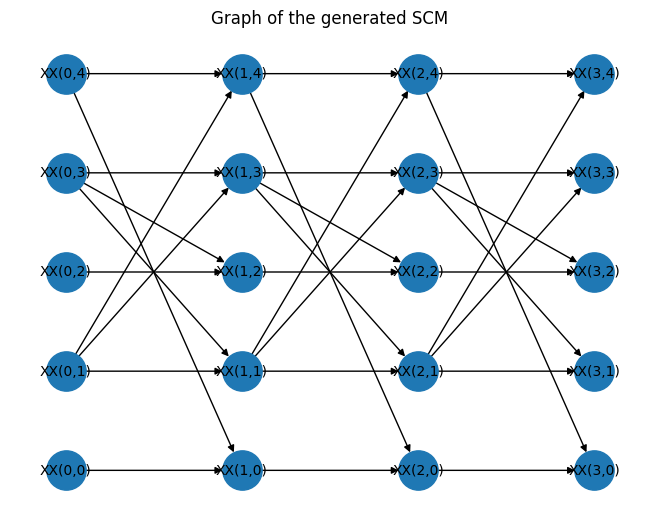

In [164]:
G=create_graph(parent_matrix,4)
arrays_node= [node.strip('X').strip('(').strip(')').split(',') for node in G.nodes()]
pos = {node_name: [int(coords[0]), int(coords[1])] for node_name, coords in zip(G.nodes(), arrays_node)}
labels = {node: f"X{node}" for node in G.nodes()}
nx.draw(G, with_labels=True, pos=pos, labels=labels, node_size=800, font_size=10)
plt.title("Graph of the generated SCM")
plt.show()

### Q4 - Plot the generated MTS using diagnostic tools.

You may use matplotlib plot functions, statsmodels plotting utilities https://www.statsmodels.org/dev/graphics.html#time-series-plots, ...

Noteworthily, you can plot the cross-correlation function between different covariate TS (for each lag) with statsmodels plot_accf_grid.

**Interpretation Question**: According to the cross-correlation, which pairs of covariates are not related? Does this match the graph? Was this expected and why?

In [165]:
# @title
#Solve the issue I heve with temporal shift
#plot_accf_grid doesn't work (takes too much time)
"""
from statsmodels.graphics.tsaplots import plot_accf_grid
plot_accf_grid(observation_matrix, lags=2)
plt.show()
"""

' \nfrom statsmodels.graphics.tsaplots import plot_accf_grid\nplot_accf_grid(observation_matrix, lags=2)\nplt.show()\n'

### Q5 - Apply µ to discover the parents of covariate 0.

The documentation is available here: https://ev07.github.io/minimal_chronoepilogi/api/chronoepilogi/

Initialize the ChronoEpilogi instance using `__init__`, launch the algorithm with `fit`, and recover the Markov Boundary computed by the forward backward phases with `get_first_markov_boundary()`.

Only the `__init__` method requires you to specify parameters. You will need to specify at the minimum:
  - data: transform the observation matrix into a pandas DataFrame, with covariate as columns and observations (timestamps) as rows. Column names should be of type str
  - target: the name of the covariate you want to obtain a Markov Boundary of
  - phases: only include forward and backward phases
  - default_max_lag: the lookback window size


In [166]:
from chronoepilogi import ChronoEpilogi
import pandas as pd
import numpy as np

# The 'data' for ChronoEpilogi should be the observation_matrix,
# with covariates as columns and observations (timestamps) as rows.
# observation_matrix has shape (D, T), so transpose it to (T, D).
# Column names should be strings.
data_df = pd.DataFrame(observation_matrix.T, columns=[str(i) for i in range(D)])

# Initialize ChronoEpilogi for target '0'
tss_instance_0 = ChronoEpilogi(data=data_df, target="0", phases="FB", default_max_lag=L)
tss_instance_0.fit()
mb_0 = tss_instance_0.get_first_markov_boundary()

# Initialize ChronoEpilogi for target '1'
tss_instance_1 = ChronoEpilogi(data=data_df, target="1", phases="FB", default_max_lag=L)
tss_instance_1.fit()
mb_1 = tss_instance_1.get_first_markov_boundary()

print(f"Markov Boundary for target '0': {mb_0}, Markov Boundary for target '1': {mb_1}")

Markov Boundary for target '0': ['0', '4'], Markov Boundary for target '1': ['1', '3']


**Interpretation question**
Does this correspond to the ground truth?

for X0 and X1 it does correspond to the ground truth because X0t is caused by X0t-1 and X4t-1 and X1t caused by X1t-1 and X3t-1.

In [167]:
print("Ground Truth Parent Matrix:\n", parent_matrix)

Ground Truth Parent Matrix:
 [[[1.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [1.]
  [0.]
  [1.]
  [1.]]

 [[0.]
  [0.]
  [1.]
  [0.]
  [0.]]

 [[0.]
  [1.]
  [1.]
  [1.]
  [0.]]

 [[1.]
  [0.]
  [0.]
  [0.]
  [1.]]]


## Q6 - Apply ChronoEpilogi to discover the parents of all TS.

Using the fact that L=1, we can compute a estimated_parent_matrix: create a numpy array of shape (D,D,1) such that $mat[cause][effect][0]$ is 1 for every cause-effect pairs, 0 otherwise.

Then, use the create_graph function to obtain a graph estimated by ChronoEpilogi, and plot it as you did at Question 3.

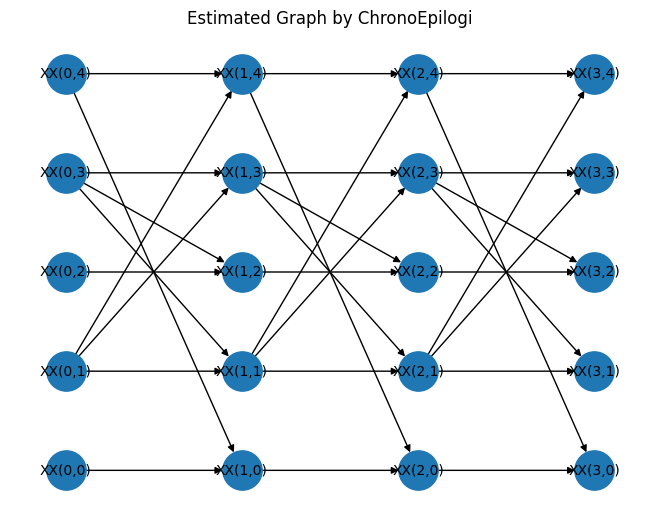

In [168]:
estimated_parent_matrix = np.zeros((D, D, L))

for child_idx in range(D):
  # Initialize ChronoEpilogi for each target covariate
  tss_instance = ChronoEpilogi(data=data_df, target=str(child_idx), phases="FB", default_max_lag=L)
  tss_instance.fit()
  # Get the Markov Boundary (estimated parents) for the current target
  mb = tss_instance.get_first_markov_boundary()

  for parent_str in mb:
    parent_idx = int(parent_str)
    # Assuming L=1, a direct causal link means parent at t-1 affects child at t
    # The parent_matrix indexing is [cause][effect][k], where k is the lag from L-1 back to 0
    # For L=1, k can only be 0, meaning effect at t is caused by cause at t-1.
    # So, if parent_idx causes child_idx, set estimated_parent_matrix[parent_idx][child_idx][0] = 1
    estimated_parent_matrix[parent_idx][child_idx][0] = 1


# Visualize the estimated Causal Graph
representation_length = 4
G_estimated = create_graph(estimated_parent_matrix, representation_length)
arrays_node_estimated = [node.strip('X').strip('(').strip(')').split(',') for node in G_estimated.nodes()]
pos_estimated = {node_name: [int(coords[0]), int(coords[1])] for node_name, coords in zip(G_estimated.nodes(), arrays_node_estimated)}
labels_estimated = {node: f"X{node}" for node in G_estimated.nodes()}
nx.draw(G_estimated, with_labels=True, pos=pos_estimated, labels=labels_estimated, node_size=800, font_size=10)
plt.title("Estimated Graph by ChronoEpilogi")
plt.show()

### Q7 - Compute the distance between the two graphs using networkx `graph_edit_distance`. Explain what this distance is and conclude.

In [169]:
G1=create_graph(parent_matrix,4)
G2=create_graph(estimated_parent_matrix,4)
print(f"Graph Edit Distance between Ground Truth and ChronoEpilogi: {nx.graph_edit_distance(G1,G2)}")
#It works very well

Graph Edit Distance between Ground Truth and ChronoEpilogi: 0.0


### Q8 - Baseline: use PCMCI (https://jakobrunge.github.io/tigramite/#tigramite.pcmci.PCMCI), already installed alongside ChronoEpilogi, to discover the graph.

You will need a tigramite DataFrame object, the PCMCI class and a independence test object.

When calling the `run_pcmci` method, remember to set tau_min=1: this prevents PCMCI from considering contemporaneous (lag 0) relationships between series.

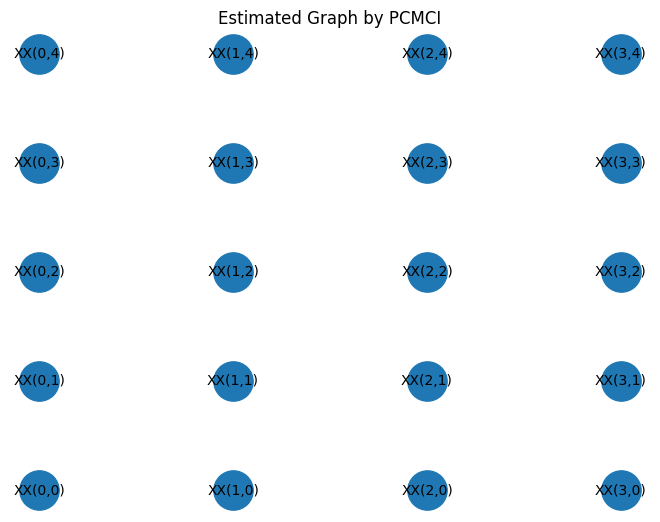

In [170]:
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

data = tigramite.data_processing.DataFrame(observation_matrix.T, var_names=list(map(str, range(D))))

parcorr = ParCorr()
pcmci = PCMCI(dataframe=data, cond_ind_test=parcorr, verbosity=0)

# Run PCMCI with tau_min=1 to prevent contemporaneous relationships
# tau_max is set to L, which was 1 in this case.
results = pcmci.run_pcmci(tau_min=1, tau_max=L, pc_alpha=0.05)

# Extract the estimated parent matrix from PCMCI results
# The results['p_matrix'] contains p-values for each potential causal link.
# We need to determine significant links.
estimated_parent_matrix_pcmci = np.zeros((D, D, L))

# Iterate through all potential links found by PCMCI
for j in range(D): # child
    for i in range(D): # parent
        # Check if a link from parent i to child j exists at lag k
        # PCMCI results are structured as (source_var, target_var, -lag)
        # We need to map this to our (cause, effect, lag) convention
        # For L=1, the only lag is 1 (index 0 in our matrix for L-1)
        if L == 1:
            # The p-matrix has shape (target_var, source_var, lag_idx)
            # where lag_idx=0 corresponds to lag=1 (t-1)
            p_val = results['p_matrix'][j, i, 0] # p-value for link i -> j at lag 1
            if p_val < 0.05: # Using a significance level of 0.05
                estimated_parent_matrix_pcmci[i, j, 0] = 1


# Visualize the estimated Causal Graph from PCMCI
representation_length = 4
G_pcmci = create_graph(estimated_parent_matrix_pcmci, representation_length)
arrays_node_pcmci = [node.strip('X').strip('(').strip(')').split(',') for node in G_pcmci.nodes()]
pos_pcmci = {node_name: [int(coords[0]), int(coords[1])] for node_name, coords in zip(G_pcmci.nodes(), arrays_node_pcmci)}
labels_pcmci = {node: f"X{node}" for node in G_pcmci.nodes()}
nx.draw(G_pcmci, with_labels=True, pos=pos_pcmci, labels=labels_pcmci, node_size=800, font_size=10)
plt.title("Estimated Graph by PCMCI")
plt.show()

In [171]:
G1=create_graph(parent_matrix,4)
G2=create_graph(estimated_parent_matrix,4)
print(f"Graph Edit Distance between Ground Truth and ChronoEpilogi: {nx.graph_edit_distance(G1,G2)}")

G_pcmci=create_graph(estimated_parent_matrix_pcmci,4)
print(f"Graph Edit Distance between Ground Truth and PCMCI: {nx.graph_edit_distance(G1,G_pcmci)}")

Graph Edit Distance between Ground Truth and ChronoEpilogi: 0.0
Graph Edit Distance between Ground Truth and PCMCI: 30.0


No values respond for PCMI (all calculated p_val=1). For tau_min=0 it does work (not perfectly though) so I suspect the PCMI is made for multivariate time series and not unvariates ones.

## Part 2 - Time Series Selection without Faithfulness

We will simulate a exemple similar to the pipe exemple in the course, with the addition of 1) stagnating water Downstream and 2) water leak at Midstream.
  - The Up node (index 0) receives a somewhat random amount of water following a normal law N(1,0.05).
  - The Mid node (index 1) receives the value of the Up node at the previous timestep.
  - The Down node (index 2) receives 0.8 times the value of the Mid node at the previous timestep, due to a water leak. Additionally, it receives 0.2 times the previous timestep of the Down node as water is stagnating at the bottom.

### Q9 - Generate T=10000 steps of the above process. Plot the graph. Plot the accf grid.

You can start by computing a noise matrix which is 0 for Mid and Down and N(1,0.05) for Up. Make sure to use a seeded random generator.

You can then generate the L=1 parent matrix of shape (3,3,1), with only three coefficients valued at 1: (0 (up), 1 (mid)) and (1 (mid), 2 (down)) representing the two pipe transitions, and (2,2) representing the stagnating water.

You can generate a coefficient matrix by instead setting the coefficient of (1,2) at 0.8 and the coefficient of (2,2) to 0.1.

Finally, you can apply the `varsim(coefficient_matrix,noise_matrix)` function.

Don't forget to plot the graph and the accf grid plot.

In [150]:
import numpy as np
import matplotlib.pyplot as plt

def fast_acf(x, nlags):
    x = x - np.mean(x)
    corr = np.correlate(x, x, mode='full')
    mid = len(corr) // 2
    corr = corr[mid:mid+nlags+1]
    return corr / corr[0]

def fast_acf_grid(observation_matrix, lags=20):
    D, T = observation_matrix.shape
    fig, axes = plt.subplots(D, 1, figsize=(6, 2*D))

    if D == 1:
        axes = [axes]

    for i in range(D):
        acf_vals = fast_acf(observation_matrix[i], lags)
        axes[i].stem(range(lags+1), acf_vals)
        axes[i].set_title(f"ACF of X{i}")
        axes[i].set_ylim(-1, 1)

    plt.tight_layout()
    return fig

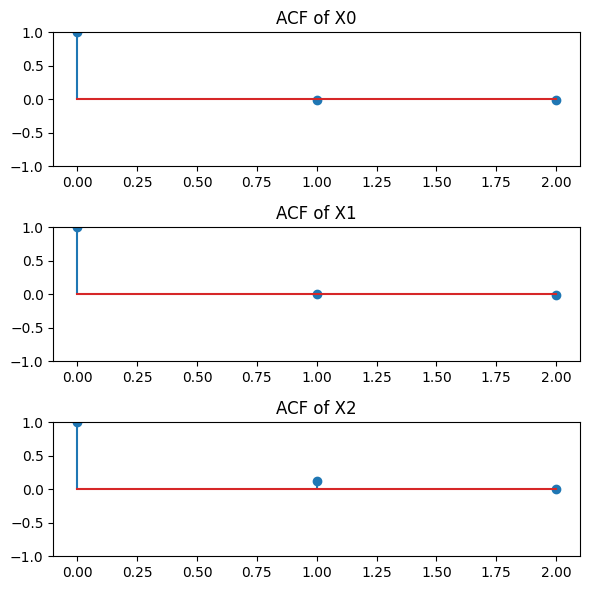

[[1.08314684 0.95294965 0.92475918 ... 1.06208296 0.98882513 1.07187177]
 [0.92910659 2.14443033 2.08210517 ... 1.96095238 2.1057209  2.03407254]
 [0.86823188 1.8592211  2.8530009  ... 2.90662249 2.78174451 3.01470022]]


In [173]:
noise_matrix = np.zeros((3,10000))
noise_matrix[0,:] = np.random.normal(1,0.05,10000)
noise_matrix[1,:] = np.random.normal(1,0.05,10000)
noise_matrix[2,:] = np.random.normal(1,0.05,10000)
parent_matrix = np.zeros((3,3,1))
parent_matrix[0,1,0] = 1
parent_matrix[1,2,0] = 1
parent_matrix[2,2,0] = 1
coefficient_matrix = np.zeros((3,3,1))
coefficient_matrix[0,1,0] = 1
coefficient_matrix[1,2,0] = 0.8
coefficient_matrix[2,2,0] = 0.1
observation_matrix = varsim(coefficient_matrix,noise_matrix)

fast_acf_grid(observation_matrix, lags=2)
plt.show()

print(observation_matrix)

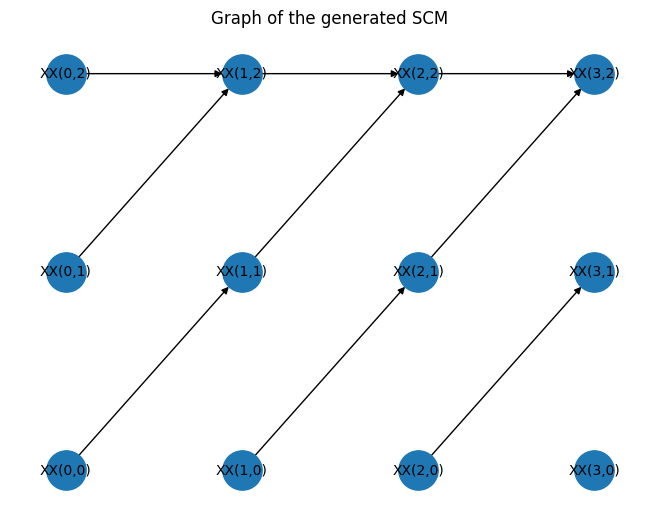

In [175]:
G=create_graph(parent_matrix,4)
arrays_node= [node.strip('X').strip('(').strip(')').split(',') for node in G.nodes()]
pos = {node_name: [int(coords[0]), int(coords[1])] for node_name, coords in zip(G.nodes(), arrays_node)}
labels = {node: f"X{node}" for node in G.nodes()}
nx.draw(G, with_labels=True, pos=pos, labels=labels, node_size=800, font_size=10)
plt.title("Graph of the generated SCM")
plt.show()

If coefficient_matrix[2,2,0] was put higher we would see ACF the second stem of X2 being much higher. We could consider there is no autocorellation for X0 (as expected) and X1 and a subtle one for X2 (we start to see the effect of the parent).

### Q10 - Run the equivalence detection on top of the forward-backward phases to find the Markov Boundaries of the downstream node (index 2).

You will need to set phases: "FBEV" for the full equivalence protocol.

What happen when the default_max_lag is 1? When it is 2?

In [ ]:
#TODO

In [ ]:
#TODO


---

**High dimensional data exemple**

Run the following cell to generate a large MTS.

In [ ]:
rng = np.random.default_rng(0)
D=400
L=10
T=10000
p=10
noise_matrix = generate_noise(D,T,rng)
parent_matrix = generate_parents(D, L, p, rng)
coefficient_matrix = generate_coefficients(parent_matrix, rng)
observation_matrix = varsim(coefficient_matrix,noise_matrix)
# artificial equivalence generation
zero_parents = np.where(parent_matrix[:,0,:].sum(axis=1)==1)[0][1:]
replaced_equivalences = np.sort(rng.choice([i for i in range(D) if i not in zero_parents],p,replace=False))
for index, ts in enumerate(replaced_equivalences):
  replacement_weights = scipy.special.softmax([3 if index==i else -3 for i in range(p)])
  observation_matrix[ts,:] = np.sum(replacement_weights[:,np.newaxis]*observation_matrix[zero_parents,:],axis=0)

data = pd.DataFrame(observation_matrix.T,columns=list(map(str,range(len(observation_matrix)))))


In [ ]:
print("Parents of node 0:\t\t",zero_parents)
print("Respective equivalences:\t",replaced_equivalences)

### Q11 - Apply ChronoEpilogi to this dataset for target "0". Compare the Markov Boundaries found to the parent set and the generated equivalences.

In [ ]:
# TODO

### Q12 - Scalability - Apply ChronoEpilogi with 2,8,16, and 32 lags. Time each call to `fit` and plot the increase in computation time on a graph. *Warning: approximately 5min computation time*

In [ ]:
# TODO

In [ ]:
# TODO

## Part 3 - Real data forecasting

Download the Electricity dataset (https://cloud.etis-lab.fr/index.php/s/pYWZPL8PwJnitBY).

Alternatively, it is present here but requires preprocessing due to the tsf format (https://zenodo.org/records/4656140), so it is unadivsed.

It records the electricity consumption of different clients. It is sampled hourly, and has no missing values.

In [ ]:
data = pd.read_csv("electricity.csv",index_col="Unnamed: 0")
data.index = pd.to_datetime(data.index)
data.index.freq = "H"

### Q13 - Analyse some of the covariate TS individually with diagnostic tools such as plots and the autocorrelation function.

In [ ]:
# TODO

The following code removes seasonality with the dataframe.

Execute the code.

In [ ]:
data_noseasonal = []
for column in data.columns:
  data_noseasonal.append(statsmodels.tsa.seasonal.seasonal_decompose(data[column]).resid)
data_noseasonal = pd.concat(data_noseasonal,axis=1)
data_noseasonal.columns = data.columns
data_noseasonal = data_noseasonal.dropna()

data_noseasonal


### Q14 - Visualize and compare some of the series before and after detrending and seasonality removal. Is seasonality removal successful?

In [ ]:
# TODO

In [ ]:
#TODO

### Q15 - Apply ChronoEpilogi single solution algorithm to forecast "T1". An appropriate lookback window is 4 days.

Don't forget to use data_noseasonal and not data.

In [ ]:
#TODO

### Q16 - Forecast the future of "T1" with the previous Markov Boundary as predictors.

You will use the ForecasterDirectMultiVariate class of skforecast, with estimator LGBMRegressor.

Same as before, an appropriate lookback window is 4 days. You will forecast a 1 day horizon.

In the next cell, two folds are defined. One is a training fold, which you will use during the call to the `fit` method. The other is the test, which you will compare to the predictions of the `predict` method.

If model training is too long, consider modifying the parameters of the LGBMRegressor. For instance, reducing max_bin to 31, n_estimators to 100, or feature_fraction to 0.1 or 0.2.

In [ ]:
data_train = data_noseasonal.iloc[:-24]
data_test = data_noseasonal.iloc[-24:]

In [ ]:
# TODO

In [ ]:
#TODO

### Q BONUS - Compute predictive metrics using the backtesting_forecaster interface.

In [ ]:
# TODO